## PHASE 1: DATA PREPARATION
### Federated Learning Breast Cancer Detection Project

### This notebook preprocesses all 3 datasets:
#### - WDBC (Hospital 1) - Tabular cell features
#### - Coimbra (Hospital 2) - Tabular blood biomarkers
#### - BreakHis (Hospital 3) - Histopathology images


### Setting Working Directory

In [1]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
os.chdir('..')
print("Changing to root directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: 'D:\MY FILES\BREAST_CANCER_FL\notebooks'
Changing to root directory...
Working in: 'D:\MY FILES\BREAST_CANCER_FL'


### 1. Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import shutil
import pickle
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Sklearn for preprocessing and splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# SMOTE for class balancing
from imblearn.over_sampling import SMOTE

# PyTorch for image preprocessing
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

# Setting random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


### 2. Creating Processed Data Directories

In [3]:
os.makedirs('data/processed/wdbc', exist_ok=True)
os.makedirs('data/processed/coimbra', exist_ok=True)
os.makedirs('data/processed/breakhis/train/benign', exist_ok=True)
os.makedirs('data/processed/breakhis/train/malignant', exist_ok=True)
os.makedirs('data/processed/breakhis/test/benign', exist_ok=True)
os.makedirs('data/processed/breakhis/test/malignant', exist_ok=True)

print("Directory structure created!")
print("\nProcessed data will be saved to:")
print("  - data/processed/wdbc/")
print("  - data/processed/coimbra/")
print("  - data/processed/breakhis/")

Directory structure created!

Processed data will be saved to:
  - data/processed/wdbc/
  - data/processed/coimbra/
  - data/processed/breakhis/


## PART A: WDBC PREPROCESSING (Hospital 1)

### 3. Loading WDBC Dataset

In [15]:
wdbc = pd.read_csv('data/raw/wdbc/data.csv')

print("WDBC DATASET - INITIAL EXPLORATION")
print("="*70)
print(f"Shape(row,col): {wdbc.shape}")
print(f"\nFirst few rows:")
print(wdbc.head())
print(f"\nColumns: {list(wdbc.columns)}")
print(f"\nData types:")
print(wdbc.dtypes)
print(f"\nClass distribution:")
print(wdbc['diagnosis'].value_counts())

WDBC DATASET - INITIAL EXPLORATION
Shape(row,col): (569, 33)

First few rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980          

-   **Data Volume**: The dataset consists of  **569 records**  with  **33 columns**.
-   **Target Distribution**:
    -   **Benign (B)**: 357 samples (~63%)
    -   **Malignant (M)**: 212 samples (~37%)
    -   The dataset is relatively well-balanced, though Benign samples slightly outnumber Malignant ones.
-   **Feature Characteristics**:
    -   The features represent 10 real-valued attributes of cell nuclei (e.g., radius, texture, perimeter) calculated in three ways:  **Mean**,  **Standard Error (se)**, and  **Worst**  (mean of the three largest values), totaling 30 predictive features.
    -   All predictive features are stored as  **float64**  data types, which is ideal for numerical modeling.
-   **Data Quality Issues**:
    -   **Extraneous Column**: There is a column named  `Unnamed: 32`  containing  `NaN`  values, likely due to a trailing comma in the raw CSV. This will need to be dropped.
    -   **Non-Predictive Column**: The  `id`  column is a unique identifier and should be removed before training to prevent the model from "memorizing" patient IDs.
    -   **Label Encoding**: The  `diagnosis`  target is currently categorical (Object) and will require encoding (e.g., B=0, M=1) for machine learning algorithms.

### 4. Preprocess WDBC

### Step 1

In [16]:
# Dropping ID column (not needed for modeling)
wdbc_processed = wdbc.drop(['id', 'Unnamed: 32'], axis=1)
print("Dropped 'id' & 'Unnamed: 32' column")

# Encoding diagnosis labels (M=1, B=0)
label_encoder = LabelEncoder()
wdbc_processed['diagnosis'] = label_encoder.fit_transform(wdbc_processed['diagnosis'])
print("Encoded labels: M (Malignant) = 1, B (Benign) = 0")
print(f"  Class distribution after encoding:")
print(wdbc_processed['diagnosis'].value_counts())

# Checking for missing values
print(f"\n Missing values check:")
missing = wdbc_processed.isnull().sum().sum()
if missing == 0:
    print("  No missing values found!")
else:
    print(f"  Found {missing} missing values")
    wdbc_processed = wdbc_processed.dropna()

# Separating features and labels
X_wdbc = wdbc_processed.drop('diagnosis', axis=1)
y_wdbc = wdbc_processed['diagnosis']

print(f"\n Separated features and labels")
print(f"  Features shape: {X_wdbc.shape}")
print(f"  Labels shape: {y_wdbc.shape}")


Dropped 'id' & 'Unnamed: 32' column
Encoded labels: M (Malignant) = 1, B (Benign) = 0
  Class distribution after encoding:
diagnosis
0    357
1    212
Name: count, dtype: int64

 Missing values check:
  No missing values found!

 Separated features and labels
  Features shape: (569, 30)
  Labels shape: (569,)


### Step 2

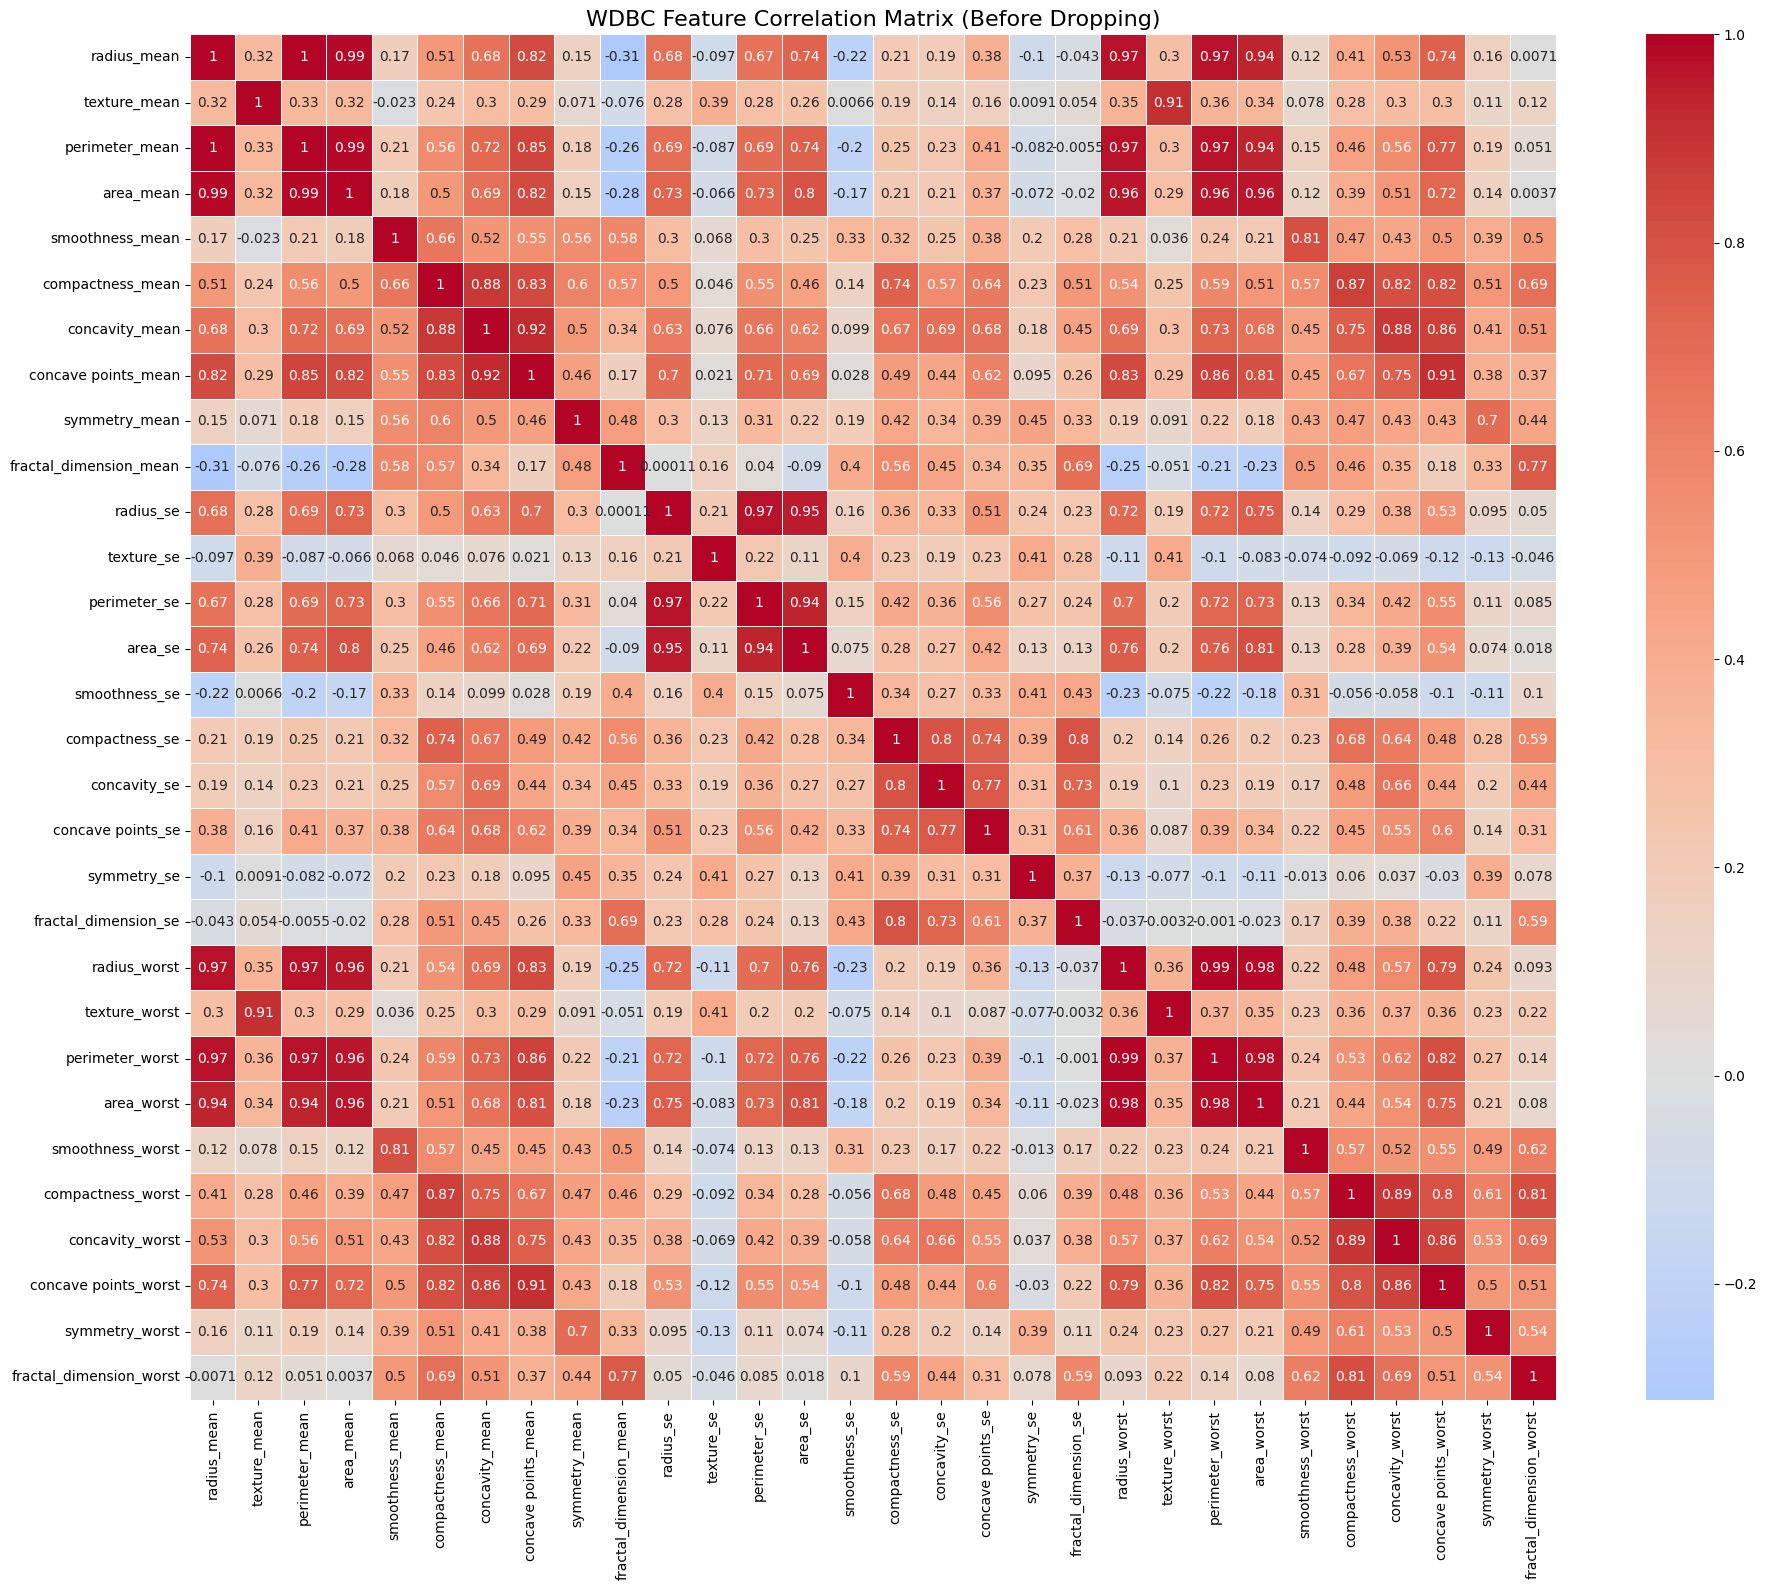

✅ Correlation matrix saved.


In [17]:
# Plotting full correlation matrix (before dropping highly correlated features)
plt.figure(figsize=(20, 16))
correlation_matrix = X_wdbc.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,          
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('WDBC Feature Correlation Matrix (Before Dropping)', fontsize=16)
plt.tight_layout()
plt.savefig('results/plots/wdbc_correlation_matrix_before.png', dpi=150)
plt.show()
print("✅ Correlation matrix saved.")

### Step 3

In [18]:
# Finding and dropping highly correlated features (> 0.95)
def drop_high_correlation(X, threshold=0.95):
    """
    Drops one feature from each pair where correlation exceeds threshold.
    Returns cleaned dataframe and list of dropped columns.
    """
    corr_matrix = X.corr().abs()  # absolute correlation values

    # Get upper triangle of correlation matrix only
    # (to avoid duplicate pairs)
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Find columns where correlation exceeds threshold
    cols_to_drop = [
        col for col in upper_triangle.columns
        if any(upper_triangle[col] > threshold)
    ]

    print(f"\n  Features dropped (correlation > {threshold}):")
    for col in cols_to_drop:
        # Find which feature it was correlated with
        correlated_with = upper_triangle.index[
            upper_triangle[col] > threshold
        ].tolist()
        print(f"   - '{col}' correlated with {correlated_with}")

    X_cleaned = X.drop(columns=cols_to_drop)
    return X_cleaned, cols_to_drop


# Run the function
X_wdbc_cleaned, dropped_cols = drop_high_correlation(X_wdbc, threshold=0.95)
y_wdbc_cleaned = y_wdbc.reset_index(drop=True)

print(f"\n- Original feature count : {X_wdbc.shape[1]}")
print(f"- Features dropped       : {len(dropped_cols)}")
print(f"- Remaining features     : {X_wdbc_cleaned.shape[1]}")
print(f"- Remaining feature names: {list(X_wdbc_cleaned.columns)}")


  Features dropped (correlation > 0.95):
   - 'perimeter_mean' correlated with ['radius_mean']
   - 'area_mean' correlated with ['radius_mean', 'perimeter_mean']
   - 'perimeter_se' correlated with ['radius_se']
   - 'area_se' correlated with ['radius_se']
   - 'radius_worst' correlated with ['radius_mean', 'perimeter_mean', 'area_mean']
   - 'perimeter_worst' correlated with ['radius_mean', 'perimeter_mean', 'area_mean', 'radius_worst']
   - 'area_worst' correlated with ['area_mean', 'radius_worst', 'perimeter_worst']

- Original feature count : 30
- Features dropped       : 7
- Remaining features     : 23
- Remaining feature names: ['radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'texture_worst', 'smoothness_worst', 'compactness_worst', 'conca

### Step 4

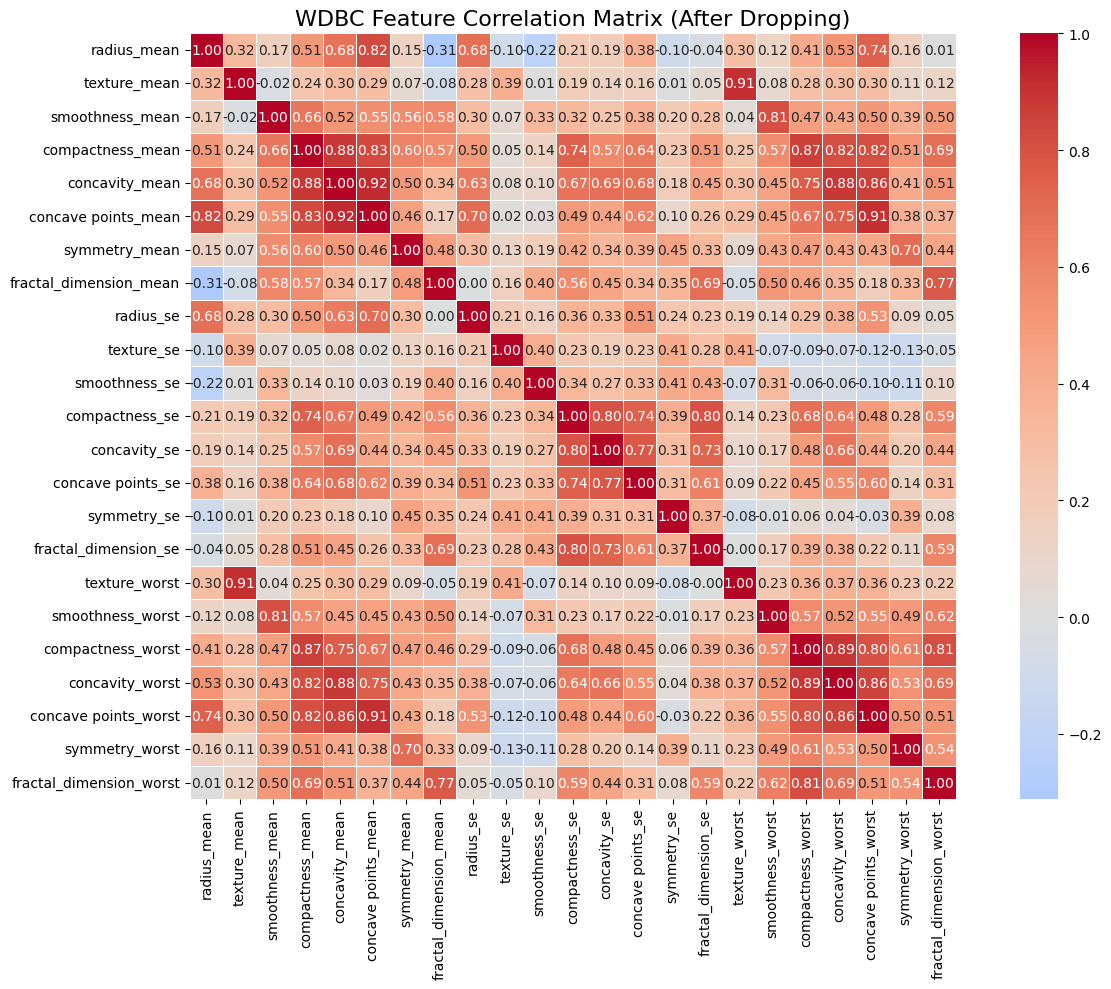

✅ Cleaned correlation matrix saved.


In [19]:
# Plotting correlation matrix after dropping
plt.figure(figsize=(14, 10))
correlation_matrix_cleaned = X_wdbc_cleaned.corr()

sns.heatmap(
    correlation_matrix_cleaned,
    annot=True,           # now fewer features so annotations are readable
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('WDBC Feature Correlation Matrix (After Dropping)', fontsize=16)
plt.tight_layout()
plt.savefig('results/plots/wdbc_correlation_matrix_after.png', dpi=150)
plt.show()
print("✅ Cleaned correlation matrix saved.")

### Step 5

In [20]:
# Splitting into train/test (80/20)
X_train_wdbc, X_test_wdbc, y_train_wdbc, y_test_wdbc = train_test_split(
    X_wdbc_cleaned, y_wdbc_cleaned, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_wdbc_cleaned # prevents class bias during splitting
)

print(f"\n Train/Test split (80/20):")
print(f"  Training set: {X_train_wdbc.shape[0]} samples")
print(f"  Test set: {X_test_wdbc.shape[0]} samples")
print(f"  Train class distribution:")
print(pd.Series(y_train_wdbc).value_counts())
print(f"  Test class distribution:")
print(pd.Series(y_test_wdbc).value_counts())

# Checking class imbalance
class_counts = pd.Series(y_train_wdbc).value_counts()
wdbc_imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n Class imbalance check:")
print(f"  Class 0 (Benign): {class_counts[0]}")
print(f"  Class 1 (Malignant): {class_counts[1]}")
print(f"  Imbalance ratio: {wdbc_imbalance_ratio:.2f}:1")

# Applying SMOTE only if imbalance ratio > 1.5
if wdbc_imbalance_ratio > 1.5:
    print(f"\n  Applying SMOTE to balance classes...")
    smote = SMOTE(random_state=42)
    X_wdbc_balanced, y_wdbc_balanced = smote.fit_resample(X_train_wdbc, y_train_wdbc)
    print(f"  SMOTE applied!")
    print(f"    New class distribution:")
    print(pd.Series(y_wdbc_balanced).value_counts())
else:
    print(f"  Class balance is acceptable. Skipping SMOTE.")
    X_wdbc_balanced = X_train_wdbc
    y_wdbc_balanced = y_train_wdbc

# Normalizing features using StandardScaler
scaler_wdbc = StandardScaler()
X_train_wdbc_scaled = scaler_wdbc.fit_transform(X_wdbc_balanced)
X_test_wdbc_scaled  = scaler_wdbc.transform(X_test_wdbc)  # same scaler, no refit
X_train_wdbc_scaled = pd.DataFrame(X_train_wdbc_scaled, columns=X_wdbc_cleaned.columns)

train_mean = X_train_wdbc_scaled.mean().mean()
train_std  = X_train_wdbc_scaled.std().mean()

print(f"\n🔍 Normalization verification:")
print(f"   Train mean (should be ~0) : {train_mean:.6f}")
print(f"   Train std  (should be ~1) : {train_std:.6f}")

print(f"\n Features normalized using StandardScaler")
print(f"  Sample of normalized data:")
print(X_train_wdbc_scaled.head())


 Train/Test split (80/20):
  Training set: 455 samples
  Test set: 114 samples
  Train class distribution:
diagnosis
0    285
1    170
Name: count, dtype: int64
  Test class distribution:
diagnosis
0    72
1    42
Name: count, dtype: int64

 Class imbalance check:
  Class 0 (Benign): 285
  Class 1 (Malignant): 170
  Imbalance ratio: 1.68:1

  Applying SMOTE to balance classes...
  SMOTE applied!
    New class distribution:
diagnosis
1    285
0    285
Name: count, dtype: int64

🔍 Normalization verification:
   Train mean (should be ~0) : -0.000000
   Train std  (should be ~1) : 1.000878

 Features normalized using StandardScaler
  Sample of normalized data:
   radius_mean  texture_mean  smoothness_mean  compactness_mean  \
0     0.324508      0.777269        -1.113904         -0.829776   
1    -0.681220     -1.756370         0.408979         -0.773145   
2    -0.537156      0.340596        -1.594854         -0.530831   
3     0.020072      0.611473         0.164466          1.998306   

### 5. Save WDBC Preprocessed Data

In [21]:
# Saving as CSV files
pd.DataFrame(X_train_wdbc_scaled).to_csv('data/processed/wdbc/X_train.csv', index=False)
pd.DataFrame(X_test_wdbc_scaled).to_csv('data/processed/wdbc/X_test.csv', index=False)
pd.DataFrame(y_wdbc_balanced, columns=['diagnosis']).to_csv('data/processed/wdbc/y_train.csv', index=False)
pd.DataFrame(y_test_wdbc, columns=['diagnosis']).to_csv('data/processed/wdbc/y_test.csv', index=False)

# Saving scaler for future use to scale new data exactly the same way as training data
with open('data/processed/wdbc/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_wdbc, f)

print(" WDBC preprocessed data saved to:")
print("  - data/processed/wdbc/X_train.csv")
print("  - data/processed/wdbc/X_test.csv")
print("  - data/processed/wdbc/y_train.csv")
print("  - data/processed/wdbc/y_test.csv")
print("  - data/processed/wdbc/scaler.pkl")

 WDBC preprocessed data saved to:
  - data/processed/wdbc/X_train.csv
  - data/processed/wdbc/X_test.csv
  - data/processed/wdbc/y_train.csv
  - data/processed/wdbc/y_test.csv
  - data/processed/wdbc/scaler.pkl


## PART B: COIMBRA PREPROCESSING (Hospital 2)

### 6. Load Coimbra Dataset

In [5]:
coimbra = pd.read_csv('data/raw/coimbra/dataR2.csv')

print("="*70)
print("COIMBRA DATASET - INITIAL EXPLORATION")
print("="*70)
print(f"Shape: {coimbra.shape}")
print(f"\nFirst few rows:")
print(coimbra.head())
print(f"\nColumns: {list(coimbra.columns)}")
print(f"\nClass distribution:")
print(coimbra['Classification'].value_counts())

COIMBRA DATASET - INITIAL EXPLORATION
Shape: (116, 10)

First few rows:
   Age        BMI  Glucose  Insulin      HOMA   Leptin  Adiponectin  Resistin  \
0   48  23.500000       70    2.707  0.467409   8.8071     9.702400   7.99585   
1   83  20.690495       92    3.115  0.706897   8.8438     5.429285   4.06405   
2   82  23.124670       91    4.498  1.009651  17.9393    22.432040   9.27715   
3   68  21.367521       77    3.226  0.612725   9.8827     7.169560  12.76600   
4   86  21.111111       92    3.549  0.805386   6.6994     4.819240  10.57635   

     MCP.1  Classification  
0  417.114               1  
1  468.786               1  
2  554.697               1  
3  928.220               1  
4  773.920               1  

Columns: ['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1', 'Classification']

Class distribution:
Classification
2    64
1    52
Name: count, dtype: int64


### 7. Preprocess Coimbra

In [11]:
# Renaming Classification to 'label' and encode (1=Healthy/Benign, 2=Patient/Malignant)
coimbra_processed = coimbra.copy()
coimbra_processed['label'] = coimbra_processed['Classification'].map({1: 0, 2: 1})
coimbra_processed = coimbra_processed.drop('Classification', axis=1)

print(" Encoded labels: 1 (Healthy/Benign) = 0, 2 (Patient/Malignant) = 1")
print(f"  Class distribution after encoding:")
print(coimbra_processed['label'].value_counts())

# Checking for missing values
print(f"\n Missing values check:")
missing = coimbra_processed.isnull().sum().sum()
if missing == 0:
    print("  No missing values found!")
else:
    print(f"  Found {missing} missing values")
    # Impute with median if any missing
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    coimbra_processed = pd.DataFrame(
        imputer.fit_transform(coimbra_processed), 
        columns=coimbra_processed.columns
    )
    print("  Missing values imputed with median")

# Separating features and labels
X_coimbra = coimbra_processed.drop('label', axis=1)
y_coimbra = coimbra_processed['label'].astype(int)

print(f"\n Separated features and labels")
print(f"  Features shape: {X_coimbra.shape}")
print(f"  Labels shape: {y_coimbra.shape}")

# Splitting into train/test (80/20)
X_train_coimbra, X_test_coimbra, y_train_coimbra, y_test_coimbra = train_test_split(
    X_coimbra, y_coimbra, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_coimbra
)

print(f"\n Train/Test split (80/20):")
print(f"  Training set: {X_train_coimbra.shape[0]} samples")
print(f"  Test set: {X_test_coimbra.shape[0]} samples")
print(f"  Train class distribution:")
print(pd.Series(y_train_coimbra).value_counts())
print(f"  Test class distribution:")
print(pd.Series(y_test_coimbra).value_counts())

# Checking class imbalance
class_counts = pd.Series(y_train_coimbra).value_counts()
coimbra_imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n Class imbalance check:")
print(f"  Class 0 (Healthy/Benign): {class_counts[0]}")
print(f"  Class 1 (Patient/Malignant): {class_counts[1]}")
print(f"  Imbalance ratio: {coimbra_imbalance_ratio:.2f}:1")

# Applying SMOTE - small dataset benefits from balancing
if coimbra_imbalance_ratio > 1.5:
    print(f"\n  Applying SMOTE to balance classes...")
    smote = SMOTE(random_state=42)
    X_coimbra_balanced, y_coimbra_balanced = smote.fit_resample(X_train_coimbra, y_train_coimbra)
    print(f"  SMOTE applied!")
    print(f"    New class distribution:")
    print(pd.Series(y_coimbra_balanced).value_counts())
else:
    print(f"  Class balance is acceptable. Skipping SMOTE.")
    X_coimbra_balanced = X_train_coimbra
    y_coimbra_balanced = y_train_coimbra

# Normalizing features using StandardScaler
scaler_coimbra = StandardScaler()
X_train_coimbra_scaled = scaler_coimbra.fit_transform(X_coimbra_balanced)
X_test_coimbra_scaled = scaler_coimbra.transform(X_test_coimbra)
X_train_coimbra_scaled = pd.DataFrame(X_train_coimbra_scaled, columns=X_coimbra.columns)

print(f"\n Features normalized using StandardScaler")

 Encoded labels: 1 (Healthy/Benign) = 0, 2 (Patient/Malignant) = 1
  Class distribution after encoding:
label
1    64
0    52
Name: count, dtype: int64

 Missing values check:
  No missing values found!

 Separated features and labels
  Features shape: (116, 9)
  Labels shape: (116,)

 Train/Test split (80/20):
  Training set: 92 samples
  Test set: 24 samples
  Train class distribution:
label
1    51
0    41
Name: count, dtype: int64
  Test class distribution:
label
1    13
0    11
Name: count, dtype: int64

 Class imbalance check:
  Class 0 (Healthy/Benign): 41
  Class 1 (Patient/Malignant): 51
  Imbalance ratio: 1.24:1
  Class balance is acceptable. Skipping SMOTE.

 Features normalized using StandardScaler


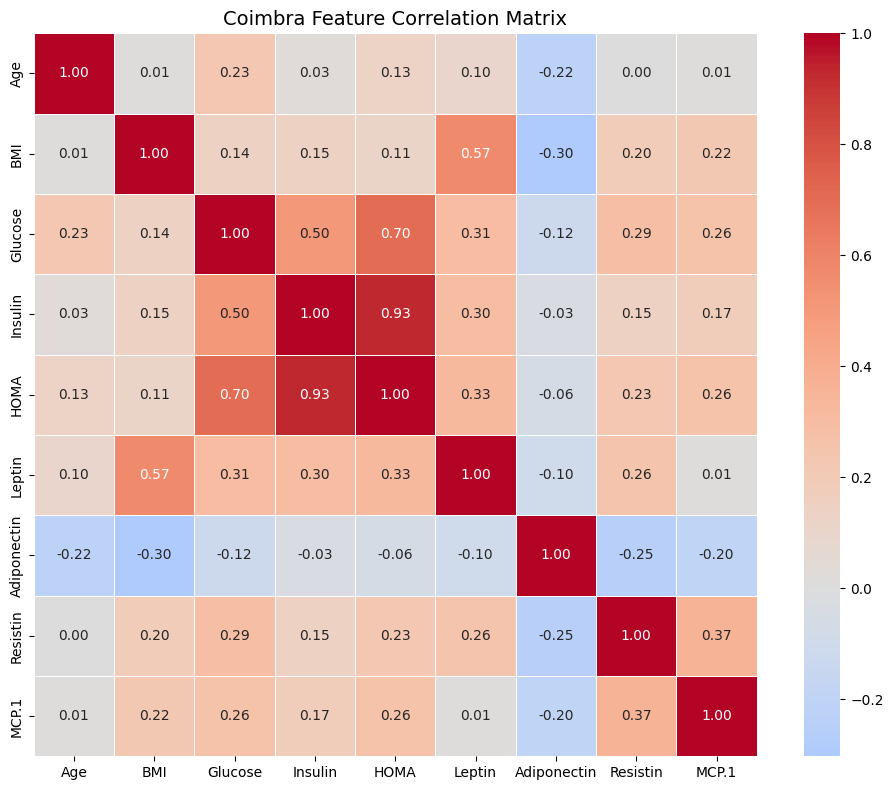


 Feature pairs with correlation > 0.95:
   No pairs found above 0.95 threshold.


In [12]:
# Plotting correlation matrix to see if high correlated(>0.95) features needs to be dropped 
plt.figure(figsize=(10, 8))
correlation_matrix = X_coimbra.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Coimbra Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('results/plots/coimbra_correlation_matrix.png', dpi=150)
plt.show()

# Print exact high correlation pairs
print("\n Feature pairs with correlation > 0.95:")
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if abs(upper.loc[row, col]) > 0.95
]

if len(high_corr_pairs) == 0:
    print("   No pairs found above 0.95 threshold.")
else:
    for col, row, val in high_corr_pairs:
        print(f"   {col} ↔ {row} : {val:.3f}.")

### 8. Save Coimbra Preprocessed Data

In [14]:
# Saving files

# X_train — scaled (92 samples)
pd.DataFrame(
    X_train_coimbra_scaled,
    columns=X_coimbra.columns
).to_csv('data/processed/coimbra/X_train.csv', index=False)

# y_train — balanced labels (92 samples)
pd.DataFrame(
    y_coimbra_balanced.values if hasattr(y_coimbra_balanced, 'values')
    else y_coimbra_balanced,
    columns=['label']
).to_csv('data/processed/coimbra/y_train.csv', index=False)

# X_test — scaled (24 samples)
pd.DataFrame(
    X_test_coimbra_scaled
).to_csv('data/processed/coimbra/X_test.csv', index=False)

# y_test — original labels (24 samples)
pd.DataFrame(
    y_test_coimbra.values if hasattr(y_test_coimbra, 'values')
    else y_test_coimbra,
    columns=['label']
).to_csv('data/processed/coimbra/y_test.csv', index=False)

# Saving scaler
with open('data/processed/coimbra/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_coimbra, f)

# Verify matching shapes
x_train_check = pd.read_csv('data/processed/coimbra/X_train.csv')
y_train_check = pd.read_csv('data/processed/coimbra/y_train.csv')
x_test_check  = pd.read_csv('data/processed/coimbra/X_test.csv')
y_test_check  = pd.read_csv('data/processed/coimbra/y_test.csv')

print(f"\n Files saved and verified:")
print(f"   X_train : {x_train_check.shape}")
print(f"   y_train : {y_train_check.shape}")
print(f"   X_test  : {x_test_check.shape}")
print(f"   y_test  : {y_test_check.shape}")


 Files saved and verified:
   X_train : (92, 9)
   y_train : (92, 1)
   X_test  : (24, 9)
   y_test  : (24, 1)


## PART C: BREAKHIS PREPROCESSING (Hospital 3)

### 9. Collect BreakHis Image Paths (100X Magnification)

In [15]:
breakhis_base = "data/raw/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
magnification = '100X'  # Using 100X as recommended

def collect_image_paths(base_path, class_type, magnification='100X'):
    """Collect image paths for a specific class and magnification"""
    image_paths = []
    class_path = os.path.join(base_path, class_type, "SOB")
    
    if not os.path.exists(class_path):
        return []
    
    for subtype in os.listdir(class_path):
        subtype_path = os.path.join(class_path, subtype)
        if os.path.isdir(subtype_path):
            for patient in os.listdir(subtype_path):
                patient_path = os.path.join(subtype_path, patient)
                if os.path.isdir(patient_path):
                    mag_path = os.path.join(patient_path, magnification)
                    if os.path.exists(mag_path):
                        for img_file in os.listdir(mag_path):
                            if img_file.endswith('.png'):
                                full_path = os.path.join(mag_path, img_file)
                                image_paths.append((full_path, 0 if class_type == 'benign' else 1))
    return image_paths

# Collecting benign and malignant image paths
print(f"Collecting {magnification} images...")
benign_paths = collect_image_paths(breakhis_base, "benign", magnification)
malignant_paths = collect_image_paths(breakhis_base, "malignant", magnification)

all_images = benign_paths + malignant_paths

print("="*70)
print(f"BREAKHIS DATASET ({magnification} Magnification)")
print("="*70)
print(f"Benign images: {len(benign_paths):,}")
print(f"Malignant images: {len(malignant_paths):,}")
print(f"Total images: {len(all_images):,}")

# Checking class imbalance
imbalance_ratio = max(len(benign_paths), len(malignant_paths)) / min(len(benign_paths), len(malignant_paths))
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

BREAKHIS DATASET (100X Magnification)
Benign images: 644
Malignant images: 1,437
Total images: 2,081
Imbalance ratio: 2.23:1


### 10. Split BreakHis into Train/Test

In [20]:
# Shuffling and splitting
np.random.shuffle(all_images)

# Separating paths and labels
image_paths = [x[0] for x in all_images]
image_labels = [x[1] for x in all_images]

# Stratified Train/Test Split using sklearn
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.2,
    random_state=42,
    stratify=image_labels  # maintains class ratio in both splits
)

# Recombining paths and labels
train_data = list(zip(train_paths, train_labels))
test_data  = list(zip(test_paths, test_labels))

# Verifying split
train_benign    = [(p, l) for p, l in train_data if l == 0]
train_malignant = [(p, l) for p, l in train_data if l == 1]
test_benign     = [(p, l) for p, l in test_data  if l == 0]
test_malignant  = [(p, l) for p, l in test_data  if l == 1]

print(f"\n✅ Train/Test Split (80/20) — Stratified:")
print(f"   Training set  : {len(train_data):,} images")
print(f"     - Benign    : {len(train_benign):,}")
print(f"     - Malignant : {len(train_malignant):,}")
print(f"     - Ratio     : {len(train_malignant)/len(train_benign):.2f}:1")
print(f"   Test set      : {len(test_data):,} images")
print(f"     - Benign    : {len(test_benign):,}")
print(f"     - Malignant : {len(test_malignant):,}")
print(f"     - Ratio     : {len(test_malignant)/len(test_benign):.2f}:1")


✅ Train/Test Split (80/20) — Stratified:
   Training set  : 1,664 images
     - Benign    : 515
     - Malignant : 1,149
     - Ratio     : 2.23:1
   Test set      : 417 images
     - Benign    : 129
     - Malignant : 288
     - Ratio     : 2.23:1


### 11. Preprocess and Save BreakHis Images

In [21]:
# STEP 1 — Defining transforms
#          Training: resize + augmentation + normalize
#          Test: resize + normalize only (no augmentation)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # randomly flips the image left-right with 50% chance. 
                                            # Teaches the model that a tumor looks the same from either side.
    transforms.RandomVerticalFlip(p=0.5), # randomly flips the image upside-down with 50% chance. 
                                          # Same idea — orientation shouldn't matter under a microscope.
    transforms.RandomRotation(degrees=15), # randomly rotates the image up to 15 degrees. 
                                           # Again, a tumor cell looks the same regardless of slight rotation.
    transforms.ColorJitter( # randomly tweaks brightness, contrast and saturation slightly. 
                            # Teaches the model to be robust to minor differences in microscope 
                            # lighting and staining conditions across hospitals.
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(                    # ImageNet stats for MobileNetV2
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(                    # same stats, no augmentation
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("  Transforms defined:")
print("   Train : augmentation + normalize (resize already done during saving)")
print("   Test  : normalize only (resize already done during saving)")

# STEP 2 — Save resized images to disk
#          Normalization will be applied during DataLoader
#          NOT during saving (standard practice)

def preprocess_and_save_image(img_path, label, split, target_size=(224, 224)):
    try:
        img = Image.open(img_path).convert('RGB')

        # Resizing
        img_resized = img.resize(target_size, Image.LANCZOS) # LANCZOS preserves more detail during downsampling.
                                                             # Better for histopathology images where fine details matter.

        class_name = 'benign' if label == 0 else 'malignant'
        save_dir  = f'data/processed/breakhis/{split}/{class_name}'
        os.makedirs(save_dir, exist_ok=True)

        filename  = os.path.basename(img_path)
        save_path = os.path.join(save_dir, filename)
        img_resized.save(save_path, quality=95)  # high quality save

        # Verifying saved image is loadable
        verify = Image.open(save_path)
        verify.verify()  # checks file integrity

        return True
    except Exception as e:
        print(f"    Error processing {img_path}: {e}")
        return False

# Processing training images
print("\n📸 Processing and saving training images...")
train_success, train_failed = 0, 0
for img_path, label in tqdm(train_data, desc="Train dataset"):
    if preprocess_and_save_image(img_path, label, 'train'):
        train_success += 1
    else:
        train_failed += 1

print(f"     Success : {train_success}/{len(train_data)}")
print(f"     Failed  : {train_failed}/{len(train_data)}")

# Processing test images
print("\n📸 Processing and saving test images...")
test_success, test_failed = 0, 0
for img_path, label in tqdm(test_data, desc="Test dataset"):
    if preprocess_and_save_image(img_path, label, 'test'):
        test_success += 1
    else:
        test_failed += 1

print(f"     Success : {test_success}/{len(test_data)}")
print(f"     Failed  : {test_failed}/{len(test_data)}")


# STEP 3 — Defining PyTorch Dataset class
#          Applies transforms during loading (not during saving)

class BreakHisDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir  = data_dir
        self.transform = transform
        self.images    = []
        self.labels    = []

        # Loading benign
        benign_dir = os.path.join(data_dir, 'benign')
        for fname in os.listdir(benign_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                self.images.append(os.path.join(benign_dir, fname))
                self.labels.append(0)

        # Loading malignant
        malignant_dir = os.path.join(data_dir, 'malignant')
        for fname in os.listdir(malignant_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                self.images.append(os.path.join(malignant_dir, fname))
                self.labels.append(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img   = Image.open(self.images[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# STEP 4 — Handling class imbalance using WeightedRandomSampler
train_dataset = BreakHisDataset(
    'data/processed/breakhis/train',
    transform=train_transform
)
test_dataset = BreakHisDataset(
    'data/processed/breakhis/test',
    transform=test_transform
)

# Computing class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_dataset.labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"\n  Class weights computed:")
print(f"   Benign weight    : {class_weights[0]:.4f}")
print(f"   Malignant weight : {class_weights[1]:.4f}")

# WeightedRandomSampler — gives more weight to minority class
sample_weights = [
    class_weights[label] for label in train_dataset.labels
]
sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# STEP 5 — Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,       # handles class imbalance
    num_workers=2,
    pin_memory=True        # faster GPU transfer
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,         # never shuffle test data
    num_workers=2,
    pin_memory=True
)

print(f"\n  DataLoaders created:")
print(f"   Train batches : {len(train_loader)}")
print(f"   Test batches  : {len(test_loader)}")


# STEP 6 — Summary
print("\n" + "=" * 45)
print("   BREAKHIS PREPROCESSING FINAL SUMMARY")
print("=" * 45)
print(f"  Train images total    : {len(train_dataset):,}")
print(f"  Train benign          : {train_dataset.labels.count(0):,}")
print(f"  Train malignant       : {train_dataset.labels.count(1):,}")
print(f"  Test images total     : {len(test_dataset):,}")
print(f"  Test benign           : {test_dataset.labels.count(0):,}")
print(f"  Test malignant        : {test_dataset.labels.count(1):,}")
print(f"  Image size            : 224x224")
print(f"  Resize method         : LANCZOS")
print(f"  Augmentation          : Yes (train only)")
print(f"  Normalization         : ImageNet mean/std")
print(f"  Class imbalance       : WeightedRandomSampler")
print(f"  Reproducibility seed  : 42")
print(f"  Data leakage          : Prevented")

  Transforms defined:
   Train : augmentation + normalize (resize already done during saving)
   Test  : normalize only (resize already done during saving)

📸 Processing and saving training images...


Train dataset: 100%|██████████████████████████████████████████████████████████████| 1664/1664 [00:37<00:00, 44.25it/s]


     Success : 1664/1664
     Failed  : 0/1664

📸 Processing and saving test images...


Test dataset: 100%|█████████████████████████████████████████████████████████████████| 417/417 [00:09<00:00, 41.89it/s]

     Success : 417/417
     Failed  : 0/417

  Class weights computed:
   Benign weight    : 1.6285
   Malignant weight : 0.7215

  DataLoaders created:
   Train batches : 63
   Test batches  : 24

   BREAKHIS PREPROCESSING FINAL SUMMARY
  Train images total    : 1,990
  Train benign          : 611
  Train malignant       : 1,379
  Test images total     : 743
  Test benign           : 225
  Test malignant        : 518
  Image size            : 224x224
  Resize method         : LANCZOS
  Augmentation          : Yes (train only)
  Normalization         : ImageNet mean/std
  Class imbalance       : WeightedRandomSampler
  Reproducibility seed  : 42
  Data leakage          : Prevented


### 12. Create Image Statistics File

In [22]:
import json

dataset_info = {
    'train_total'     : len(train_dataset),
    'test_total'      : len(test_dataset),
    'train_benign'    : train_dataset.labels.count(0),
    'train_malignant' : train_dataset.labels.count(1),
    'test_benign'     : test_dataset.labels.count(0),
    'test_malignant'  : test_dataset.labels.count(1),
    'class_weight_benign'    : class_weights[0],
    'class_weight_malignant' : class_weights[1],
    'image_size'      : [224, 224],
    'normalization'   : {
        'mean' : [0.485, 0.456, 0.406],
        'std'  : [0.229, 0.224, 0.225]
    }
}

with open('data/processed/breakhis/dataset_info.json', 'w') as f:
    json.dump(dataset_info, f, indent=4)

print(f"\n  Dataset info saved to dataset_info.json")


  Dataset info saved to dataset_info.json


## FINAL SUMMARY

### 13. Preprocessing Summary

In [23]:
print("\n" + "="*70)
print("PREPROCESSING COMPLETE!")
print("="*70)

summary = f"""
** WDBC (Hospital 1):
   - Training samples: {X_train_wdbc_scaled.shape[0]}
   - Test samples: {X_test_wdbc_scaled.shape[0]}
   - Features: {X_train_wdbc_scaled.shape[1]}
   - Normalized: Yes (StandardScaler)
   - SMOTE applied: {'Yes' if imbalance_ratio > 1.5 else 'No'}

** Coimbra (Hospital 2):
   - Training samples: {X_train_coimbra_scaled.shape[0]}
   - Test samples: {X_test_coimbra_scaled.shape[0]}
   - Features: {X_train_coimbra_scaled.shape[1]}
   - Normalized: Yes (StandardScaler)
   - SMOTE applied: Yes

** BreakHis (Hospital 3):
   - Training images: {dataset_info['train_total']:,}
     • Benign: {dataset_info['train_benign']:,}
     • Malignant: {dataset_info['train_malignant']:,}
   - Test images: {dataset_info['test_total']:,}
     • Benign: {dataset_info['test_benign']:,}
     • Malignant: {dataset_info['test_malignant']:,}
   - Magnification: {magnification}
   - Image size: 224x224 pixels
   - Normalization: Mean: {dataset_info['normalization']['mean']}
                    STD:  {dataset_info['normalization']['std']}

** All processed data saved to: data/processed/
"""
print(summary)
print("="*70)

# Saving summary
with open('data/processed/preprocessing_summary.txt', 'w') as f:
    f.write(summary)

print("\n✓ Summary saved to: data/processed/preprocessing_summary.txt")


PREPROCESSING COMPLETE!

** WDBC (Hospital 1):
   - Training samples: 455
   - Test samples: 114
   - Features: 30
   - Normalized: Yes (StandardScaler)
   - SMOTE applied: Yes

** Coimbra (Hospital 2):
   - Training samples: 102
   - Test samples: 24
   - Features: 9
   - Normalized: Yes (StandardScaler)
   - SMOTE applied: Yes

** BreakHis (Hospital 3):
   - Training images: 1,990
     • Benign: 611
     • Malignant: 1,379
   - Test images: 743
     • Benign: 225
     • Malignant: 518
   - Magnification: 100X
   - Image size: 224x224 pixels
   - Normalization: Mean: [0.485, 0.456, 0.406]
                    STD:  [0.229, 0.224, 0.225]

** All processed data saved to: data/processed/


✓ Summary saved to: data/processed/preprocessing_summary.txt
